# System Cost & Cost-Benefit Analysis

Analysis of battery storage investment economics using dispatch cost (objective function)
from 432 solved PyPSA scenarios (TYNDP 2024, National Trends, 2030).

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

ROOT = Path(".").resolve().parent  # from scenario_analysis/
DATA = ROOT / "data" / "tyndp2024" / "preprocessed" / "solved"

# Load scenario results
results = pd.read_csv(ROOT / "solved_networks_core" / "solve_results.csv")
results = results[results["status"] == "solved"].copy()

# Load base battery capacity
static_su = pd.read_parquet(DATA / "static_storage_units.parquet")
bat_base = static_su[static_su["carrier"] == "battery"]
BASE_BAT_GW = bat_base["p_nom"].sum() / 1e3  # 62.33 GW

# Compute battery GW per scenario
results["battery_gw"] = BASE_BAT_GW * results["battery_scale"]

print(f"Scenarios: {len(results)}")
print(f"Base battery capacity: {BASE_BAT_GW:.1f} GW")
print(f"Objective range: {results['objective'].min()/1e9:.1f} \u2013 {results['objective'].max()/1e9:.1f} bn EUR/yr")

Scenarios: 432
Base battery capacity: 62.3 GW
Objective range: 42.9 – 72.8 bn EUR/yr


In [82]:
# === CAPEX ===
# Source: Danish Energy Agency, Technology Catalogue, Technology 180
# File: costs_2030.csv from PyPSA/technology-data
# URL: https://github.com/PyPSA/technology-data
# URL: https://ens.dk/en/analyses-and-statistics/technology-data-energy-storage
C_INV = 170.14   # EUR/kW -- battery inverter (power component)
C_STO = 151.00   # EUR/kWh -- battery storage (energy component)

def capex_dea(duration_h):
    """DEA-based CAPEX in EUR/kW. Source: costs_2030.csv, 2020 EUR."""
    return C_INV + C_STO * duration_h

def capex_tyndp(duration_h):
    """TYNDP-scaled CAPEX in EUR/kW.
    Source: GENERATOR.csv, NT 2030 (716,480 EUR/MW for ~2h system).
    URL: https://2024.entsos-tyndp-scenarios.eu/download/
    """
    return 716 * (C_INV + C_STO * duration_h) / capex_dea(2)

# === Annualization ===
# Discount rate: 7% -- ENTSO-E CBA methodology (ACER Recommendation 02/2023)
# Lifetime: 15 years -- NREL ATB 2024 utility-scale battery reference
#   URL: https://atb.nrel.gov/electricity/2024/utility-scale_battery_storage
# O&M: 2.5% CAPEX/yr -- NREL ATB 2024; confirmed by TYNDP (17,912/716,480 = 2.50%)
DISCOUNT_RATE = 0.07
LIFETIME = 15
OM_RATE = 0.025

def crf(r, n):
    """Capital Recovery Factor: r(1+r)^n / ((1+r)^n - 1)."""
    return r * (1 + r)**n / ((1 + r)**n - 1)

CRF = crf(DISCOUNT_RATE, LIFETIME)
ANNUAL_FACTOR = CRF + OM_RATE

print(f"CRF (r={DISCOUNT_RATE}, n={LIFETIME}): {CRF:.4f}")
print(f"Annualization factor (CRF + O&M): {ANNUAL_FACTOR:.4f}")
print(f"\nCAPEX per duration (DEA / TYNDP):")
for d in [1, 2, 3, 4]:
    print(f"  {d}h: {capex_dea(d):.0f} / {capex_tyndp(d):.0f} EUR/kW")

CRF (r=0.07, n=15): 0.1098
Annualization factor (CRF + O&M): 0.1348

CAPEX per duration (DEA / TYNDP):
  1h: 321 / 487 EUR/kW
  2h: 472 / 716 EUR/kW
  3h: 623 / 945 EUR/kW
  4h: 774 / 1174 EUR/kW


## A. System Cost & Benefit-Cost Ratio

Dispatch cost (objective) = total annual fuel + CO₂ + VOM costs across all 55 zones.
Battery investment is NOT in the objective — we compute it ex-post to determine if the
dispatch cost savings justify the investment.

**Financial assumptions used in all heatmaps:**

| Parameter | Value | Source |
|---|---|---|
| Discount rate | 7% | ENTSO-E CBA guidelines |
| Lifetime | 15 years | DEA Technology Catalogue |
| O&M rate | 2.5% of CAPEX/yr | TYNDP / NREL ATB |
| CRF | 0.1098 | = r(1+r)^n / ((1+r)^n - 1) |
| Annual factor | 0.1348 | = CRF + O&M |

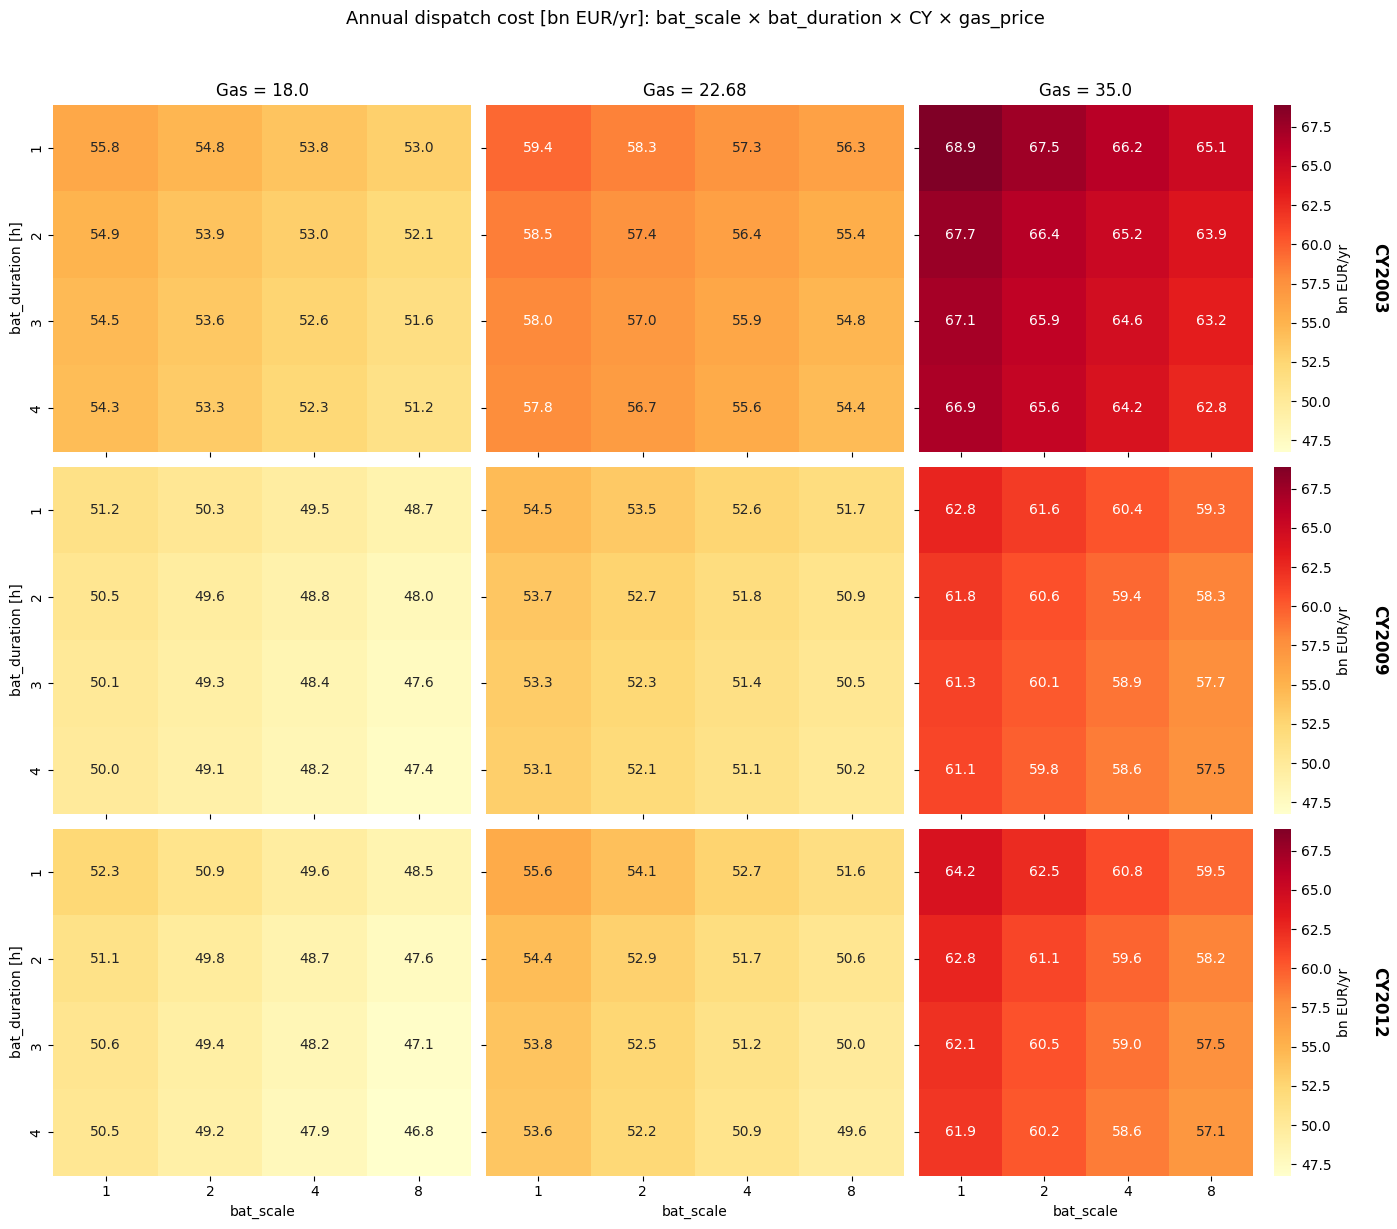

In [83]:
# System cost — 3×3 grid: CY rows × gas cols, bat_scale × bat_duration heatmap inside
CYS = sorted(results["climate_year"].unique())
GAS = sorted(results["gas_price"].unique())

fig, axes = plt.subplots(3, 3, figsize=(14, 12), sharex=True, sharey=True)

all_medians = results.groupby(["climate_year", "gas_price", "battery_duration", "battery_scale"])["objective"].median() / 1e9
vmin, vmax = all_medians.min(), all_medians.max()

for row, cy in enumerate(CYS):
    for col, gp in enumerate(GAS):
        ax = axes[row, col]
        sub = results[(results["climate_year"] == cy) & (results["gas_price"] == gp)]
        pivot = sub.groupby(["battery_duration", "battery_scale"])["objective"].median().reset_index()
        pivot["objective"] = pivot["objective"] / 1e9
        hm = pivot.pivot(index="battery_duration", columns="battery_scale", values="objective")

        sns.heatmap(hm, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax,
                    cbar=col == 2, vmin=vmin, vmax=vmax,
                    cbar_kws={"label": "bn EUR/yr"} if col == 2 else {})
        ax.set_xlabel("bat_scale" if row == 2 else "")
        ax.set_ylabel("bat_duration [h]" if col == 0 else "")

        if row == 0:
            ax.set_title(f"Gas = {gp}")
        if col == 2:
            ax.yaxis.set_label_position("right")
            ax.text(1.35, 0.5, f"CY{cy}", transform=ax.transAxes,
                    rotation=-90, va="center", fontsize=12, fontweight="bold")

plt.suptitle("Annual dispatch cost [bn EUR/yr]: bat_scale × bat_duration × CY × gas_price", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

### Benefit-Cost Ratio (BCR) computation

For each scenario with bat_scale > 1, we compute:

1. **Dispatch savings** = dispatch cost at bat1× − dispatch cost at batN× (same duration, gas, CO₂, CY)
2. **Annualized investment** = added GW × CAPEX(duration) × (CRF + O&M rate)
3. **BCR = dispatch savings / annualized investment**
4. **Net benefit = dispatch savings − annualized investment** (negative = loss)

BCR is computed under two CAPEX assumptions (DEA and TYNDP) and summarized as median [P25–P75] across all 9 external parameter combinations (3 gas × 3 CO₂) per climate year.

Baseline is always bat_scale=1 with the **same bat_duration** — each duration has its own baseline.






In [84]:
# Compute benefit-cost ratio for each scenario vs bat1x baseline
ctx = ["battery_duration", "gas_price", "co2_price", "climate_year"]
baseline = results[results["battery_scale"] == 1].set_index(ctx)[["objective", "battery_gw"]]

expanded = results[results["battery_scale"] > 1].copy()
idx = expanded.set_index(ctx).index
expanded["baseline_obj"] = idx.map(baseline["objective"]).values
expanded["baseline_gw"] = idx.map(baseline["battery_gw"]).values

# Delta cost and capacity
expanded["delta_cost"] = expanded["baseline_obj"] - expanded["objective"]
expanded["delta_gw"] = expanded["battery_gw"] - expanded["baseline_gw"]
expanded["delta_mw"] = expanded["delta_gw"] * 1e3

# DEA CAPEX (duration-aware)
expanded["capex_eur_kw"] = expanded["battery_duration"].apply(capex_dea)
expanded["investment_eur"] = expanded["delta_mw"] * expanded["capex_eur_kw"] * 1e3
expanded["annual_cost"] = expanded["investment_eur"] * ANNUAL_FACTOR
expanded["bcr_dea"] = expanded["delta_cost"] / expanded["annual_cost"]
expanded["net_benefit"] = expanded["delta_cost"] - expanded["annual_cost"]

# TYNDP CAPEX sensitivity
expanded["capex_tyndp"] = expanded["battery_duration"].apply(capex_tyndp)
expanded["annual_cost_tyndp"] = expanded["delta_mw"] * expanded["capex_tyndp"] * 1e3 * ANNUAL_FACTOR
expanded["bcr_tyndp"] = expanded["delta_cost"] / expanded["annual_cost_tyndp"]

# Summary table
summary = expanded.groupby(["battery_scale", "battery_duration"]).agg(
    bcr_dea_median=("bcr_dea", "median"),
    bcr_dea_p25=("bcr_dea", lambda x: x.quantile(0.25)),
    bcr_dea_p75=("bcr_dea", lambda x: x.quantile(0.75)),
    bcr_tyndp_median=("bcr_tyndp", "median"),
    net_benefit_bn=("net_benefit", lambda x: x.median() / 1e9),
).reset_index()

print("BCR Summary — median [P25–P75]  |  DEA vs TYNDP CAPEX")
print("=" * 80)
for _, r in summary.iterrows():
    print(f"  bat{r['battery_scale']:.0f}× dur{r['battery_duration']:.0f}h: "
          f"BCR(DEA)={r['bcr_dea_median']:.2f} [{r['bcr_dea_p25']:.2f}–{r['bcr_dea_p75']:.2f}]  "
          f"BCR(TYNDP)={r['bcr_tyndp_median']:.2f}  "
          f"Net={r['net_benefit_bn']:+.1f} bn EUR/yr")

BCR Summary — median [P25–P75]  |  DEA vs TYNDP CAPEX
  bat2× dur1h: BCR(DEA)=0.46 [0.38–0.54]  BCR(TYNDP)=0.31  Net=-1.4 bn EUR/yr
  bat2× dur2h: BCR(DEA)=0.30 [0.25–0.35]  BCR(TYNDP)=0.20  Net=-2.8 bn EUR/yr
  bat2× dur3h: BCR(DEA)=0.21 [0.18–0.25]  BCR(TYNDP)=0.14  Net=-4.1 bn EUR/yr
  bat2× dur4h: BCR(DEA)=0.18 [0.15–0.21]  BCR(TYNDP)=0.12  Net=-5.3 bn EUR/yr
  bat4× dur1h: BCR(DEA)=0.29 [0.24–0.35]  BCR(TYNDP)=0.19  Net=-5.7 bn EUR/yr
  bat4× dur2h: BCR(DEA)=0.19 [0.16–0.22]  BCR(TYNDP)=0.12  Net=-9.7 bn EUR/yr
  bat4× dur3h: BCR(DEA)=0.14 [0.12–0.17]  BCR(TYNDP)=0.09  Net=-13.4 bn EUR/yr
  bat4× dur4h: BCR(DEA)=0.12 [0.10–0.14]  BCR(TYNDP)=0.08  Net=-17.1 bn EUR/yr
  bat8× dur1h: BCR(DEA)=0.18 [0.15–0.21]  BCR(TYNDP)=0.12  Net=-15.5 bn EUR/yr
  bat8× dur2h: BCR(DEA)=0.12 [0.10–0.14]  BCR(TYNDP)=0.08  Net=-24.4 bn EUR/yr
  bat8× dur3h: BCR(DEA)=0.09 [0.08–0.10]  BCR(TYNDP)=0.06  Net=-33.2 bn EUR/yr
  bat8× dur4h: BCR(DEA)=0.08 [0.07–0.09]  BCR(TYNDP)=0.05  Net=-42.0 bn EUR/yr


**BCR heatmap:** Each cell shows how many cents per invested euro are returned from dispatch savings. For example, BCR = 0.65 means 65 cents return per euro invested. All values below 1.0 mean the investment does not pay for itself from dispatch savings alone.

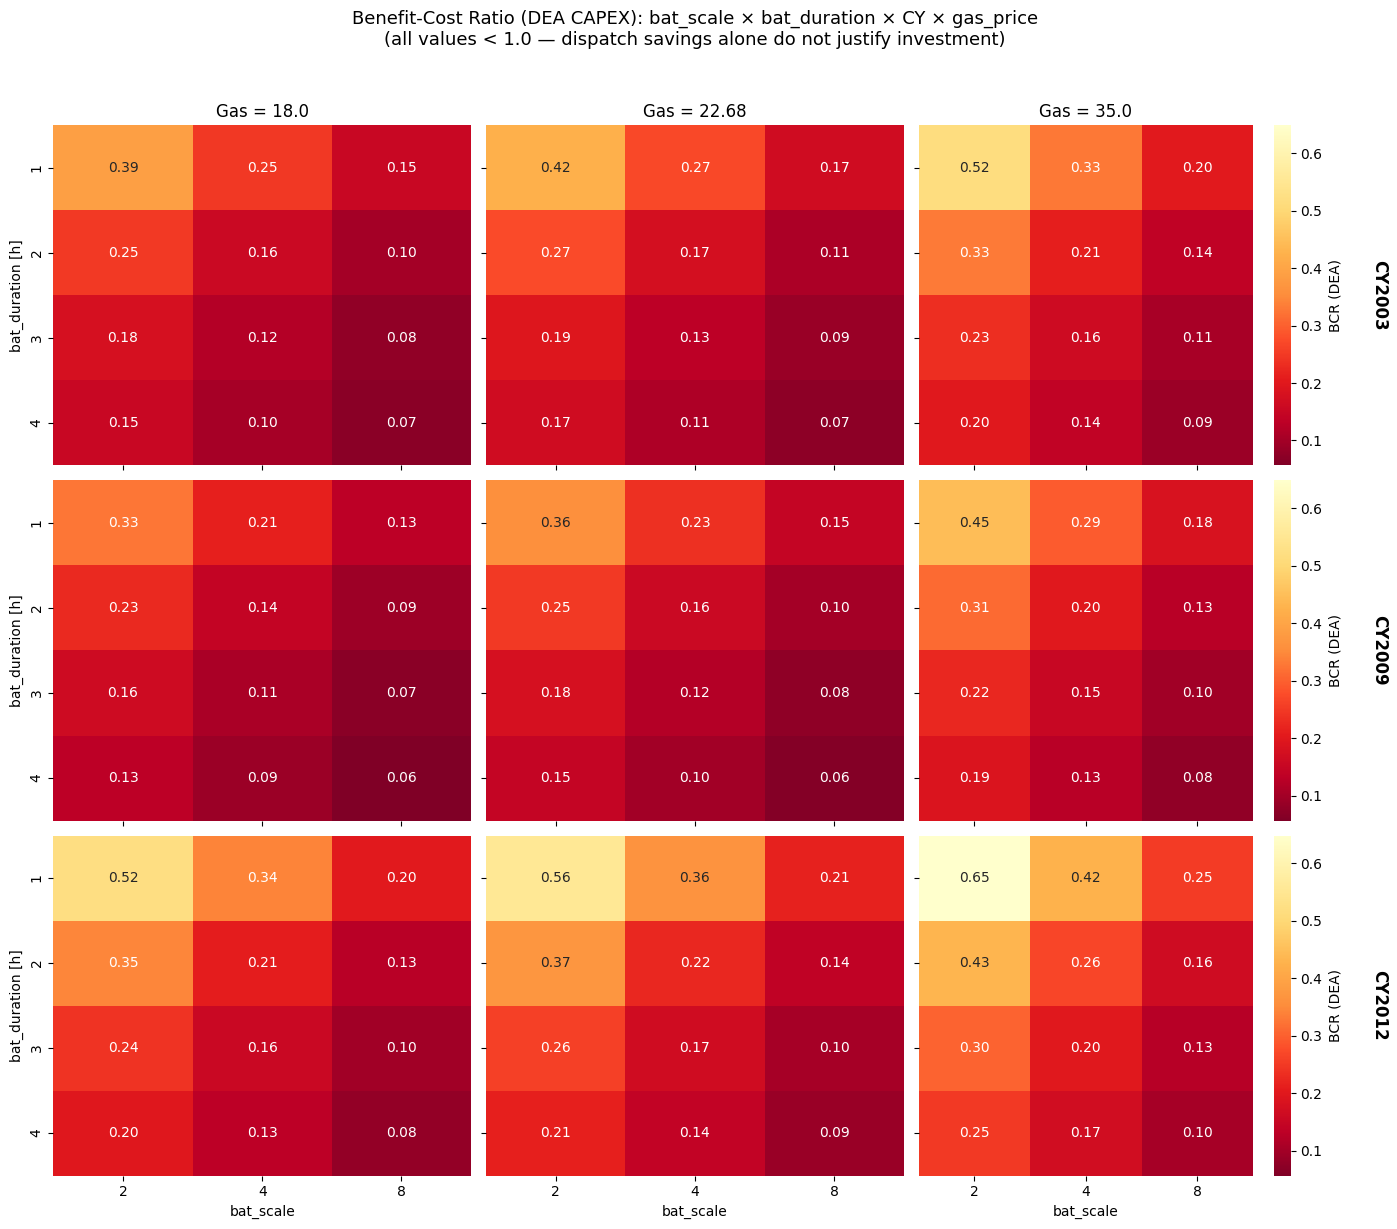

In [85]:
# BCR heatmap — 3×3 grid: CY rows × gas cols, bat_scale × bat_duration inside
CYS = sorted(expanded["climate_year"].unique())
GAS = sorted(expanded["gas_price"].unique())

fig, axes = plt.subplots(3, 3, figsize=(14, 12), sharex=True, sharey=True)

# Global color range
all_medians = expanded.groupby(["climate_year", "gas_price", "battery_duration", "battery_scale"])["bcr_dea"].median()
vmin, vmax = all_medians.min(), all_medians.max()

for row, cy in enumerate(CYS):
    for col, gp in enumerate(GAS):
        ax = axes[row, col]
        sub = expanded[(expanded["climate_year"] == cy) & (expanded["gas_price"] == gp)]
        pivot = sub.groupby(["battery_duration", "battery_scale"])["bcr_dea"].median().reset_index()
        hm = pivot.pivot(index="battery_duration", columns="battery_scale", values="bcr_dea")

        sns.heatmap(hm, annot=True, fmt=".2f", cmap="YlOrRd_r", ax=ax,
                    cbar=col == 2, vmin=vmin, vmax=vmax,
                    cbar_kws={"label": "BCR (DEA)"} if col == 2 else {})
        ax.set_xlabel("bat_scale" if row == 2 else "")
        ax.set_ylabel("bat_duration [h]" if col == 0 else "")

        if row == 0:
            ax.set_title(f"Gas = {gp}")
        if col == 2:
            ax.yaxis.set_label_position("right")
            ax.text(1.35, 0.5, f"CY{cy}", transform=ax.transAxes,
                    rotation=-90, va="center", fontsize=12, fontweight="bold")

plt.suptitle("Benefit-Cost Ratio (DEA CAPEX): bat_scale × bat_duration × CY × gas_price\n(all values < 1.0 — dispatch savings alone do not justify investment)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

### BCR sensitivity to financial assumptions

The BCR heatmap above uses fixed financial parameters (7% discount rate, 15-year lifetime). The tables below test how BCR changes under different financing conditions (4–10% discount rate, 10–20 year lifetime).

**Note:** Values here are **medians** across all gas/CO₂/CY combinations — the heatmap shows individual scenarios. For example, bat2× dur1h shows 0.65 in the best-case scenario (CY2012, Gas=35) but median BCR is 0.46. Even under the most favorable financial assumptions (4%, 20yr), median BCR stays below 1.0.

In [86]:
# Sensitivity: discount rate × lifetime for key configurations (DEA CAPEX)
configs = [
    (2, 1, "bat2× dur1h"),
    (2, 2, "bat2× dur2h"),
    (4, 1, "bat4× dur1h"),
    (8, 1, "bat8× dur1h"),
]

for bs, bd, label in configs:
    ref = expanded[(expanded["battery_scale"] == bs) & (expanded["battery_duration"] == bd)]
    
    sens_rows = []
    for r in [0.04, 0.07, 0.10]:
        for n in [10, 15, 20]:
            af = crf(r, n) + OM_RATE
            bcr_vals = ref["delta_cost"] / (ref["delta_mw"] * capex_dea(bd) * 1e3 * af)
            sens_rows.append({"discount_rate": f"{r:.0%}", "lifetime_yr": n,
                              "bcr_median": bcr_vals.median()})
    
    sens_df = pd.DataFrame(sens_rows)
    sens_pivot = sens_df.pivot(index="discount_rate", columns="lifetime_yr", values="bcr_median")
    
    print(f"Sensitivity: {label} (DEA CAPEX = {capex_dea(bd):.0f} EUR/kW)")
    print(sens_pivot.round(2).to_string())
    print()

Sensitivity: bat2× dur1h (DEA CAPEX = 321 EUR/kW)
lifetime_yr      10    15    20
discount_rate                  
10%            0.33  0.40  0.44
4%             0.42  0.54  0.63
7%             0.37  0.46  0.52

Sensitivity: bat2× dur2h (DEA CAPEX = 472 EUR/kW)
lifetime_yr      10    15    20
discount_rate                  
10%            0.21  0.26  0.28
4%             0.27  0.35  0.41
7%             0.24  0.30  0.34

Sensitivity: bat4× dur1h (DEA CAPEX = 321 EUR/kW)
lifetime_yr      10    15    20
discount_rate                  
10%            0.21  0.25  0.28
4%             0.27  0.35  0.40
7%             0.24  0.29  0.33

Sensitivity: bat8× dur1h (DEA CAPEX = 321 EUR/kW)
lifetime_yr      10    15    20
discount_rate                  
10%            0.13  0.16  0.17
4%             0.16  0.21  0.25
7%             0.15  0.18  0.20



## B. Marginal Value & Break-Even Analysis

Marginal system cost reduction per additional GW of battery capacity.
Computed as finite differences between consecutive scale levels (1→2, 2→4, 4→8).
Break-even CAPEX = the overnight cost at which adding 1 more GW is just profitable.

In [87]:
ctx = ["battery_duration", "gas_price", "co2_price", "climate_year"]
scale_order = [1, 2, 4, 8]

records = []
for keys, grp in results.groupby(ctx):
    grp = grp.sort_values("battery_scale")
    for i in range(1, len(scale_order)):
        row_from = grp[grp["battery_scale"] == scale_order[i-1]].iloc[0]
        row_to = grp[grp["battery_scale"] == scale_order[i]].iloc[0]

        delta_cost = row_from["objective"] - row_to["objective"]
        delta_gw = row_to["battery_gw"] - row_from["battery_gw"]
        mv = delta_cost / delta_gw if delta_gw > 0 else np.nan

        records.append({
            "battery_duration": keys[0], "gas_price": keys[1],
            "co2_price": keys[2], "climate_year": keys[3],
            "scale_from": scale_order[i-1], "scale_to": scale_order[i],
            "step": f"{scale_order[i-1]}x\u2192{scale_order[i]}x",
            "delta_cost_bn": delta_cost / 1e9,
            "delta_gw": delta_gw,
            "midpoint_gw": (row_from["battery_gw"] + row_to["battery_gw"]) / 2,
            "marginal_value": mv,
        })

marginals = pd.DataFrame(records)
marginals["marginal_value_m"] = marginals["marginal_value"] / 1e6

print("Marginal value summary (M EUR/yr per GW):")
print(marginals.groupby("step")["marginal_value_m"].describe()[["mean", "50%", "min", "max"]].round(0))

Marginal value summary (M EUR/yr per GW):
       mean   50%   min   max
step                         
1x→2x  19.0  19.0  12.0  30.0
2x→4x   9.0   9.0   6.0  14.0
4x→8x   4.0   4.0   3.0   6.0


### Marginal value vs annualized cost

The chart below compares the marginal dispatch savings per GW (curves) with the annualized cost per GW (dashed lines).

- **Dashed lines** = how much 1 GW of batteries costs per year (annualized CAPEX: DEA 2h = 64 M EUR/yr/GW, TYNDP 2h = 97 M EUR/yr/GW)
- **Curves** = how much 1 GW of batteries saves on dispatch costs per year (max ~20 M EUR/yr/GW at the first doubling step)

If a curve crossed a dashed line, it would mean that adding the next GW is economically justified. The curves remain 3–5× below the cost lines — the marginal value of batteries never reaches their annualized cost from dispatch savings alone.

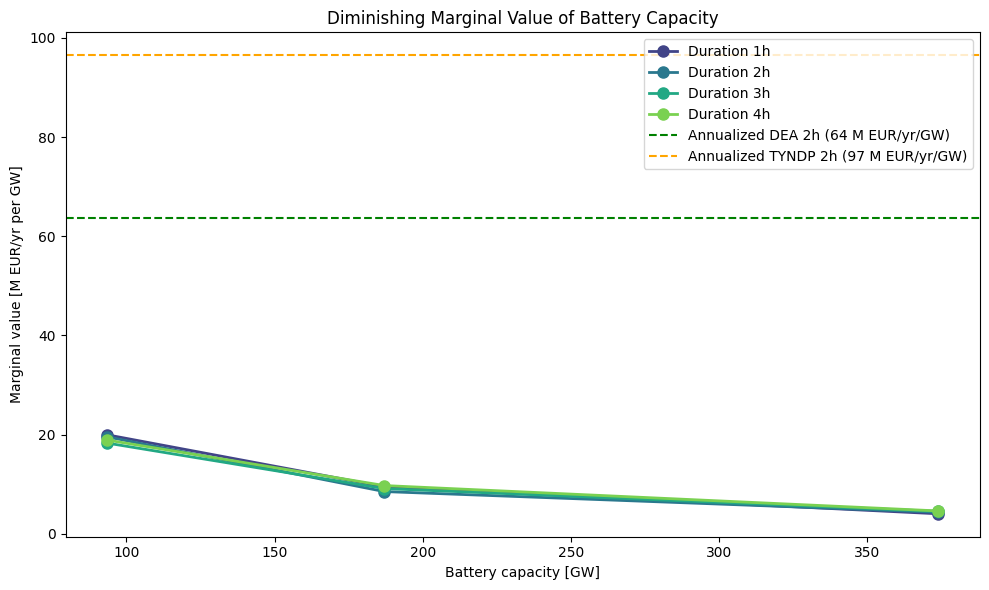

In [88]:
fig, ax = plt.subplots(figsize=(10, 6))

ann_dea_2h = capex_dea(2) * 1e6 * ANNUAL_FACTOR / 1e6   # M EUR/yr per GW
ann_tyndp_2h = capex_tyndp(2) * 1e6 * ANNUAL_FACTOR / 1e6

for dur, color in zip([1, 2, 3, 4], sns.color_palette("viridis", 4)):
    sub = marginals[marginals["battery_duration"] == dur]
    avg = sub.groupby("step")[["midpoint_gw", "marginal_value_m"]].mean().sort_values("midpoint_gw")
    ax.plot(avg["midpoint_gw"], avg["marginal_value_m"], "o-", color=color,
            label=f"Duration {dur}h", linewidth=2, markersize=8)

ax.axhline(ann_dea_2h, color="green", ls="--", lw=1.5,
           label=f"Annualized DEA 2h ({ann_dea_2h:.0f} M EUR/yr/GW)")
ax.axhline(ann_tyndp_2h, color="orange", ls="--", lw=1.5,
           label=f"Annualized TYNDP 2h ({ann_tyndp_2h:.0f} M EUR/yr/GW)")

ax.set_xlabel("Battery capacity [GW]")
ax.set_ylabel("Marginal value [M EUR/yr per GW]")
ax.set_title("Diminishing Marginal Value of Battery Capacity")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

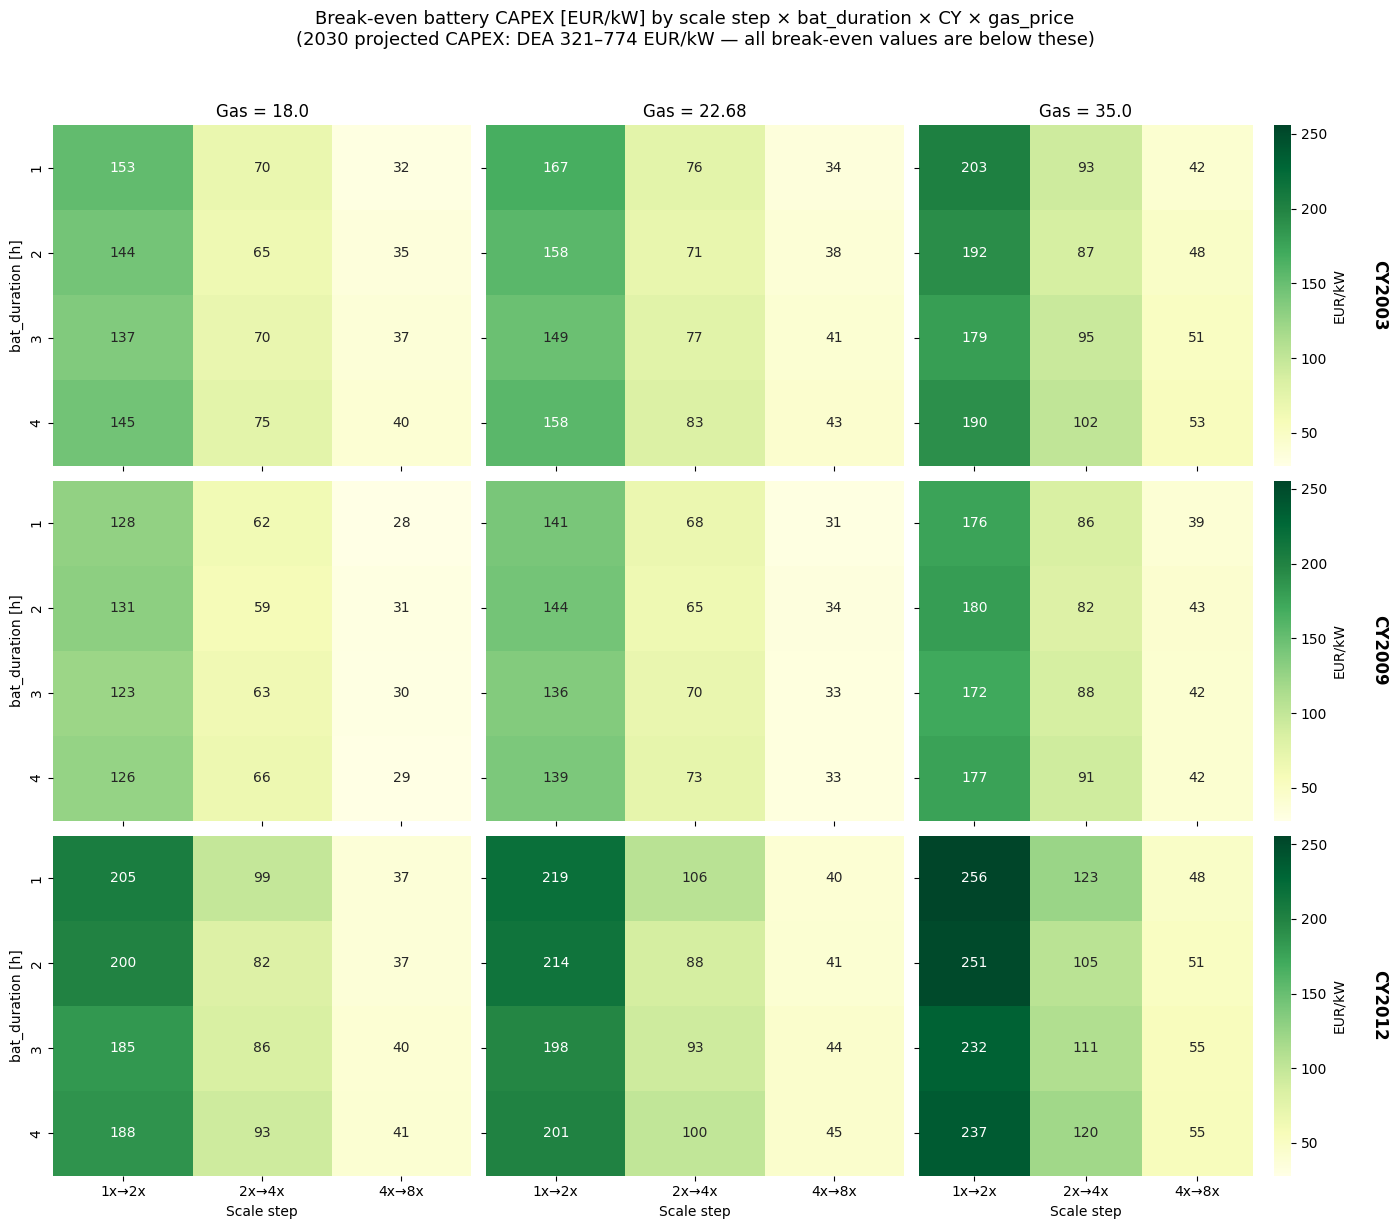

In [89]:
def breakeven_capex(mv_eur_yr_gw, r=DISCOUNT_RATE, n=LIFETIME):
    """Break-even overnight CAPEX in EUR/kW given marginal value in EUR/yr/GW."""
    return mv_eur_yr_gw / (crf(r, n) * 1e6)

# Break-even CAPEX — 3×3 grid: CY rows × gas cols, bat_duration × step inside
# Each cell shows break-even for all 3 steps at each duration
CYS = sorted(marginals["climate_year"].unique())
GAS = sorted(marginals["gas_price"].unique())

marginals_be = marginals.copy()
marginals_be["be_capex"] = marginals_be["marginal_value"].apply(breakeven_capex)

fig, axes = plt.subplots(3, 3, figsize=(14, 12), sharex=True, sharey=True)

all_vals = marginals_be.groupby(["climate_year", "gas_price", "battery_duration", "step"])["be_capex"].median()
vmin, vmax = max(0, all_vals.min()), all_vals.max()

for row, cy in enumerate(CYS):
    for col, gp in enumerate(GAS):
        ax = axes[row, col]
        sub = marginals_be[(marginals_be["climate_year"] == cy) & (marginals_be["gas_price"] == gp)]
        pivot = sub.groupby(["battery_duration", "step"])["be_capex"].median().reset_index()
        hm = pivot.pivot(index="battery_duration", columns="step", values="be_capex")
        # Reorder columns
        step_order = [s for s in ["1x→2x", "2x→4x", "4x→8x"] if s in hm.columns]
        hm = hm[step_order]

        sns.heatmap(hm, annot=True, fmt=".0f", cmap="YlGn", ax=ax,
                    cbar=col == 2, vmin=vmin, vmax=vmax,
                    cbar_kws={"label": "EUR/kW"} if col == 2 else {})
        ax.set_xlabel("Scale step" if row == 2 else "")
        ax.set_ylabel("bat_duration [h]" if col == 0 else "")

        if row == 0:
            ax.set_title(f"Gas = {gp}")
        if col == 2:
            ax.yaxis.set_label_position("right")
            ax.text(1.35, 0.5, f"CY{cy}", transform=ax.transAxes,
                    rotation=-90, va="center", fontsize=12, fontweight="bold")

plt.suptitle("Break-even battery CAPEX [EUR/kW] by scale step × bat_duration × CY × gas_price\n(2030 projected CAPEX: DEA 321–774 EUR/kW — all break-even values are below these)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## C. BCR Drivers & Climate Year Variability

Which scenario parameters most influence BCR? OLS regression quantifies relative importance.
Climate year variability shows that batteries deliver disproportionate value during high-stress periods,
though BCR remains below 1.0 even in the best case.

In [90]:
import statsmodels.api as sm

# OLS regression: what drives BCR?
regressors = ["battery_scale", "battery_duration", "gas_price", "co2_price", "climate_year"]
X = expanded[regressors].astype(float)
X = sm.add_constant(X)
y = expanded["bcr_dea"].astype(float)
model_bcr = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 10})

print("BCR regression (HAC):")
print(f"R² = {model_bcr.rsquared:.3f}, N = {len(expanded)}")
print()
for var in regressors:
    sig = "***" if model_bcr.pvalues[var] < 0.001 else "**" if model_bcr.pvalues[var] < 0.01 else "*" if model_bcr.pvalues[var] < 0.05 else "ns"
    print(f"  {var:20s}: {model_bcr.params[var]:+.5f}  (t={model_bcr.tvalues[var]:.2f}) {sig}")

# Standardized betas for comparison
X_std = (expanded[regressors] - expanded[regressors].mean()) / expanded[regressors].std()
X_std = sm.add_constant(X_std)
model_std = sm.OLS(y, X_std).fit()
print(f"\nStandardized β coefficients:")
for var in regressors:
    print(f"  {var:20s}: β = {model_std.params[var]:+.3f}")

BCR regression (HAC):
R² = 0.780, N = 324

  battery_scale       : -0.02733  (t=-22.55) ***
  battery_duration    : -0.06157  (t=-22.65) ***
  gas_price           : +0.00329  (t=4.71) ***
  co2_price           : +0.00064  (t=3.39) ***
  climate_year        : +0.00477  (t=4.87) ***

Standardized β coefficients:
  battery_scale       : β = -0.068
  battery_duration    : β = -0.069
  gas_price           : β = +0.024
  co2_price           : β = +0.016
  climate_year        : β = +0.018


## D. Consumer Surplus Decomposition

Who gains and who loses from battery deployment?
- **Consumers:** pay LMP × demand — lower LMP = savings
- **Producers:** earn LMP × generation — lower LMP = revenue loss
- **Battery operators:** earn from arbitrage (buy low, sell high)

Analysis covers 6 key scenario pairs spanning different battery scales, durations, gas prices, CO₂ prices, and climate years.

**Methodological note:** Consumer cost is approximated as LMP × bus-level generation. In the LP model, bus-level generation equals bus-level demand plus net exports. For net-exporting zones (e.g. DE00), this proxy includes the value of exported power, so results should be interpreted as total nodal surplus rather than pure consumer welfare.

In [91]:
# Load all data for welfare decomposition
lmp_all = pd.read_parquet(DATA / "lmp.parquet")
bus_cols = [c for c in lmp_all.columns if c not in ("tag", "timestamp")]

gen_p_all = pd.read_parquet(DATA / "gen_p.parquet")
gen_cols = [c for c in gen_p_all.columns if c not in ("tag", "timestamp")]

stor_p_all = pd.read_parquet(DATA / "storage_p.parquet")
stor_cols = [c for c in stor_p_all.columns if c not in ("tag", "timestamp")]

static_gen = pd.read_parquet(DATA / "static_generators.parquet")
static_su = pd.read_parquet(DATA / "static_storage_units.parquet")

print(f"Data loaded: LMP {lmp_all.shape}, gen_p {gen_p_all.shape}, stor_p {stor_p_all.shape}")

Data loaded: LMP (3784320, 57), gen_p (3784320, 559), stor_p (3784320, 121)


In [92]:
# Welfare decomposition for key scenario pairs
# Vary: bat_scale (2,8), bat_duration (1,2), gas (18,35), CY (2003,2012)
KEY_CASES = [
    {"battery_scale": 2, "battery_duration": 1, "gas_price": 22.68, "co2_price": 113.4, "climate_year": 2009, "label": "bat2× dur1h\nmid gas, CY2009"},
    {"battery_scale": 8, "battery_duration": 1, "gas_price": 22.68, "co2_price": 113.4, "climate_year": 2009, "label": "bat8× dur1h\nmid gas, CY2009"},
    {"battery_scale": 2, "battery_duration": 1, "gas_price": 35.0,  "co2_price": 113.4, "climate_year": 2012, "label": "bat2× dur1h\nhigh gas, CY2012"},
    {"battery_scale": 2, "battery_duration": 2, "gas_price": 22.68, "co2_price": 113.4, "climate_year": 2009, "label": "bat2× dur2h\nmid gas, CY2009"},
    {"battery_scale": 8, "battery_duration": 2, "gas_price": 35.0,  "co2_price": 113.4, "climate_year": 2012, "label": "bat8× dur2h\nhigh gas, CY2012"},
    {"battery_scale": 2, "battery_duration": 1, "gas_price": 35.0,  "co2_price": 140.0, "climate_year": 2012, "label": "bat2× dur1h\nhigh gas+CO₂, CY2012"},
]

gen_bus_map = static_gen["bus"]
bat_units = static_su[static_su["carrier"] == "battery"].index

welfare_results = []

for case in KEY_CASES:
    bs = case["battery_scale"]
    bd = case["battery_duration"]
    
    # Find baseline (bat1x) and target tags
    base_filter = (results["battery_scale"] == 1) & (results["battery_duration"] == bd) & \
                  (results["gas_price"] == case["gas_price"]) & (results["co2_price"] == case["co2_price"]) & \
                  (results["climate_year"] == case["climate_year"])
    tgt_filter = (results["battery_scale"] == bs) & (results["battery_duration"] == bd) & \
                 (results["gas_price"] == case["gas_price"]) & (results["co2_price"] == case["co2_price"]) & \
                 (results["climate_year"] == case["climate_year"])
    
    tag_1x = results[base_filter]["tag"].iloc[0]
    tag_tgt = results[tgt_filter]["tag"].iloc[0]
    
    # LMP
    lmp_1x = lmp_all[lmp_all["tag"] == tag_1x][bus_cols].reset_index(drop=True)
    lmp_tgt = lmp_all[lmp_all["tag"] == tag_tgt][bus_cols].reset_index(drop=True)
    
    # Gen
    gen_1x = gen_p_all[gen_p_all["tag"] == tag_1x][gen_cols].reset_index(drop=True)
    gen_tgt = gen_p_all[gen_p_all["tag"] == tag_tgt][gen_cols].reset_index(drop=True)
    
    # Consumer cost
    gen_by_bus_1x = gen_1x.T.groupby(gen_bus_map).sum().T
    gen_by_bus_tgt = gen_tgt.T.groupby(gen_bus_map).sum().T
    common = lmp_1x.columns.intersection(gen_by_bus_1x.columns)
    
    consumer_1x = (lmp_1x[common] * gen_by_bus_1x[common]).sum().sum()
    consumer_tgt = (lmp_tgt[common] * gen_by_bus_tgt[common]).sum().sum()
    delta_consumer = (consumer_1x - consumer_tgt) / 1e9
    
    # Producer revenue by carrier (top carriers only)
    prod_delta = {}
    for carrier in ["gas", "solar-pv-utility", "solar-pv-rooftop", "nuclear", "onwind", "offwind"]:
        units = static_gen[static_gen["carrier"] == carrier].index
        u_in = units.intersection(gen_1x.columns)
        if len(u_in) == 0:
            continue
        rev_1x = sum((gen_1x[u] * lmp_1x[static_gen.loc[u, "bus"]]).sum() 
                      for u in u_in if static_gen.loc[u, "bus"] in lmp_1x.columns)
        rev_tgt = sum((gen_tgt[u] * lmp_tgt[static_gen.loc[u, "bus"]]).sum() 
                      for u in u_in if static_gen.loc[u, "bus"] in lmp_tgt.columns)
        delta = (rev_1x - rev_tgt) / 1e9
        if abs(delta) > 0.01:
            prod_delta[carrier] = delta
    
    # Battery arbitrage
    stor_tgt = stor_p_all[stor_p_all["tag"] == tag_tgt][stor_cols].reset_index(drop=True)
    bat_in = bat_units.intersection(stor_tgt.columns)
    bat_rev = sum((stor_tgt[u] * lmp_tgt[static_su.loc[u, "bus"]]).sum() 
                  for u in bat_in if static_su.loc[u, "bus"] in lmp_tgt.columns) / 1e9
    
    # System cost delta
    obj_1x = results[base_filter]["objective"].iloc[0]
    obj_tgt = results[tgt_filter]["objective"].iloc[0]
    sys_delta = (obj_1x - obj_tgt) / 1e9
    
    # Investment
    added_gw = BASE_BAT_GW * (bs - 1)
    inv_annual = added_gw * 1e6 * capex_dea(bd) * ANNUAL_FACTOR / 1e9
    
    welfare_results.append({
        "label": case["label"],
        "consumer_savings": delta_consumer,
        "producer_delta": prod_delta,
        "battery_arbitrage": bat_rev,
        "sys_delta": sys_delta,
        "investment": inv_annual,
        "bcr_system": sys_delta / inv_annual if inv_annual > 0 else 0,
    })
    
    print(f"Done: {case['label'].replace(chr(10), ', ')} — BCR={sys_delta/inv_annual:.2f}")

print(f"\nComputed welfare for {len(welfare_results)} cases.")

Done: bat2× dur1h, mid gas, CY2009 — BCR=0.36
Done: bat8× dur1h, mid gas, CY2009 — BCR=0.15
Done: bat2× dur1h, high gas, CY2012 — BCR=0.65
Done: bat2× dur2h, mid gas, CY2009 — BCR=0.25
Done: bat8× dur2h, high gas, CY2012 — BCR=0.16
Done: bat2× dur1h, high gas+CO₂, CY2012 — BCR=0.69

Computed welfare for 6 cases.


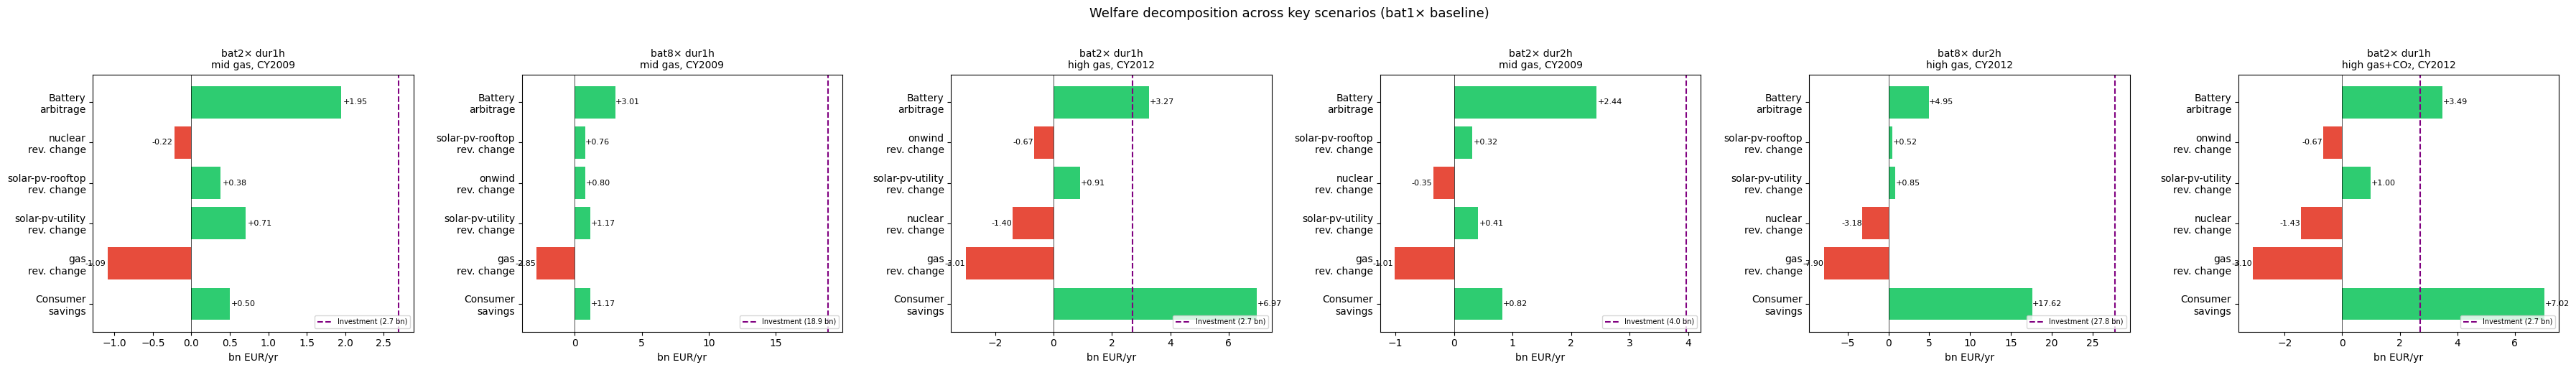

In [93]:
# Waterfall charts for all key cases
n_cases = len(welfare_results)
fig, axes = plt.subplots(1, n_cases, figsize=(6 * n_cases, 5), sharey=False)
if n_cases == 1:
    axes = [axes]

for ax, wr in zip(axes, welfare_results):
    components = {"Consumer\nsavings": wr["consumer_savings"]}
    for k, v in sorted(wr["producer_delta"].items(), key=lambda x: -abs(x[1]))[:4]:
        components[f"{k}\nrev. change"] = -v
    components["Battery\narbitrage"] = wr["battery_arbitrage"]
    
    colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in components.values()]
    
    bars = ax.barh(list(components.keys()), list(components.values()), color=colors)
    ax.axvline(0, color="black", lw=0.5)
    ax.axvline(wr["investment"], color="purple", ls="--", lw=1.5,
               label=f"Investment ({wr['investment']:.1f} bn)")
    ax.set_xlabel("bn EUR/yr")
    ax.set_title(wr["label"], fontsize=10)
    ax.legend(fontsize=7, loc="lower right")
    
    for bar, v in zip(bars, components.values()):
        ax.text(bar.get_width() + 0.02 * (1 if v >= 0 else -1), 
                bar.get_y() + bar.get_height()/2,
                f"{v:+.2f}", va="center", ha="left" if v >= 0 else "right", fontsize=8)

plt.suptitle("Welfare decomposition across key scenarios (bat1× baseline)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# Free memory
del lmp_all, gen_p_all, stor_p_all

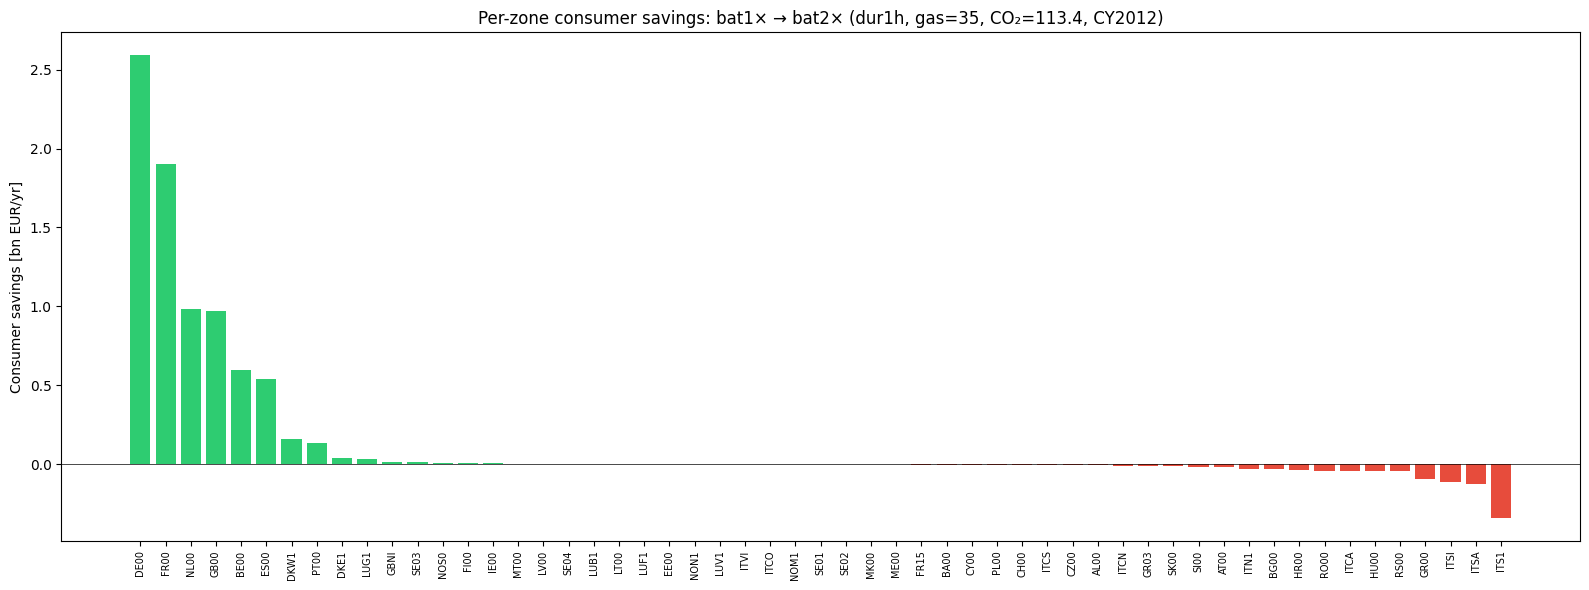

Top 10 zones by consumer savings (bn EUR/yr):
  DE00    : +2.590
  FR00    : +1.901
  NL00    : +0.983
  GB00    : +0.968
  BE00    : +0.600
  ES00    : +0.540
  DKW1    : +0.162
  PT00    : +0.133
  DKE1    : +0.038
  LUG1    : +0.033

Total: 6.97 bn EUR/yr


In [94]:
# Per-bus consumer savings for best-case scenario (bat2× dur1h, high gas=35, CY2012)
# Reload data for this specific pair
lmp_all = pd.read_parquet(DATA / "lmp.parquet")
bus_cols = [c for c in lmp_all.columns if c not in ("tag", "timestamp")]
gen_p_all = pd.read_parquet(DATA / "gen_p.parquet")
gen_cols = [c for c in gen_p_all.columns if c not in ("tag", "timestamp")]

best_base = results[
    (results["battery_scale"] == 1) & (results["battery_duration"] == 1) &
    (results["gas_price"] == 35.0) & (results["co2_price"] == 113.4) & (results["climate_year"] == 2012)
]
best_tgt = results[
    (results["battery_scale"] == 2) & (results["battery_duration"] == 1) &
    (results["gas_price"] == 35.0) & (results["co2_price"] == 113.4) & (results["climate_year"] == 2012)
]

tag_1x = best_base["tag"].iloc[0]
tag_2x = best_tgt["tag"].iloc[0]

lmp_1x = lmp_all[lmp_all["tag"] == tag_1x][bus_cols].reset_index(drop=True)
lmp_2x = lmp_all[lmp_all["tag"] == tag_2x][bus_cols].reset_index(drop=True)

gen_1x = gen_p_all[gen_p_all["tag"] == tag_1x][gen_cols].reset_index(drop=True)
gen_2x = gen_p_all[gen_p_all["tag"] == tag_2x][gen_cols].reset_index(drop=True)

static_gen = pd.read_parquet(DATA / "static_generators.parquet")
gen_bus_map = static_gen["bus"]

gen_by_bus_1x = gen_1x.T.groupby(gen_bus_map).sum().T
gen_by_bus_2x = gen_2x.T.groupby(gen_bus_map).sum().T
common = lmp_1x.columns.intersection(gen_by_bus_1x.columns)

# Per-bus consumer cost
consumer_1x = (lmp_1x[common] * gen_by_bus_1x[common]).sum()  # per bus
consumer_2x = (lmp_2x[common] * gen_by_bus_2x[common]).sum()
savings_per_bus = (consumer_1x - consumer_2x) / 1e9  # bn EUR/yr
savings_per_bus = savings_per_bus.sort_values(ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(16, 6))
colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in savings_per_bus.values]
ax.bar(range(len(savings_per_bus)), savings_per_bus.values, color=colors)
ax.set_xticks(range(len(savings_per_bus)))
ax.set_xticklabels(savings_per_bus.index, rotation=90, fontsize=7)
ax.set_ylabel("Consumer savings [bn EUR/yr]")
ax.set_title("Per-zone consumer savings: bat1× → bat2× (dur1h, gas=35, CO₂=113.4, CY2012)")
ax.axhline(0, color="black", lw=0.5)
plt.tight_layout()
plt.show()

# Top 10
print("Top 10 zones by consumer savings (bn EUR/yr):")
for zone, val in savings_per_bus.head(10).items():
    print(f"  {zone:8s}: {val:+.3f}")
print(f"\nTotal: {savings_per_bus.sum():.2f} bn EUR/yr")

del lmp_all, gen_p_all

## Summary & Limitations

### Key Findings

1. **BCR < 1 across all 432 scenarios.** Dispatch cost savings alone cannot justify battery investment under any tested combination of parameters. Best-case median BCR is 0.46 (bat2× dur1h, DEA CAPEX). This establishes a clear lower bound: additional revenue streams (ancillary services, capacity markets) are necessary for economic viability.
2. **Marginal value exhibits strong diminishing returns:** 19 → 9 → 4 M EUR/yr per GW for successive doublings (1×→2×, 2×→4×, 4×→8×). The first GW of additional batteries is worth ~5× more than the last.
3. **Break-even CAPEX** for the 1×→2× step ranges from ~80–180 EUR/kW depending on gas/CO₂ scenario — well below current market prices (DEA: 321–774 EUR/kW), confirming the gap between dispatch-only value and investment cost.
4. **Climate year variability:** CY2012 (cold winter) yields BCR up to 2.5× higher than CY2003, confirming that batteries deliver disproportionate value during high-stress periods. However, even the best CY2012 BCR remains below 1.0.
5. **Consumer surplus:** Consumers benefit from lower LMPs (0.82 bn EUR/yr saving in reference scenario), while gas generators lose revenue. Battery arbitrage revenue (2.44 bn EUR/yr) cannot offset annualized investment (3.97 bn EUR/yr).

### Important Caveats

- **Lower bound estimate:** The LP model captures only wholesale energy arbitrage value. Real-world battery revenues include FCR/aFRR ancillary services (estimated 30–50% of total revenue in European markets), capacity market payments, and network deferral value — none of which are modeled here.
- **Perfect foresight:** The LP dispatch has perfect foresight over 8760 hours, which inflates arbitrage efficiency relative to real-world operation with forecast uncertainty.
- **CAPEX trajectory:** DEA (472 EUR/kW for 2h) and TYNDP (716 EUR/kW for 2h) represent 2030 projections from 2022–2023 vintages. LFP battery pack prices fell below 100 USD/kWh in late 2024, suggesting actual 2030 system costs may be 25–30% lower than assumed.

### Limitations

1. **Energy-only valuation** — no ancillary services, capacity markets, or network deferral benefits
2. **LP relaxation** — no unit commitment, start-up costs, or minimum run times
3. **Uniform CAPEX** — same EUR/kW across all zones; real costs vary by location
4. **Section D uses a single reference scenario** — welfare decomposition results are illustrative, not generalizable across the full parameter space
5. **No CAPEX sensitivity axis** — discount rate and lifetime are varied but overnight CAPEX is fixed at DEA/TYNDP values